## MRI-ESM2-0 read-in and regridding
This notebook does the following:
- crop CMIP files to EPSG:3413 region of interest (immediately makes the files much more manageable) using function crop_cmip.py
- convert temperature and salinity into thermal forcing using function calc_cmip_TF.py
    - **Caution! `calc_cmip_TF.py` as provided in this repo includes a correction from cm to m depth units.** Check the units of your GCM file and adjust the function appropriately.  Check that your output is the correct order of magnitude using the plotting tools we provide.
- regrid CMIP output to regular grid using function regrid_cmip.py

### Setup
Note that this implementation assumes you have files stored in time slices.  You will comment/uncomment below and run the subsequent cells again for each slice.  This can certainly be updated in a for-loop or other restructuring for high performance computing.

In [1]:
# region of interest in EPSG:3413 and format [xmin,xmax,ymin,ymax]
roi = [-7.2e5,9.6e5,-3.45e6,-0.57e6]

# linear freezing point parameters
l1 = -5.73e-2
l2 = 8.32e-2
l3 = -7.61e-4

# regular grid
hres = 40e3
vres = 50

# files to process
base_dir = '/Users/eultee/Desktop/MRI-ESM2'
# historical: 1850-2014
# cmipTfile = base_dir + '/historical/Omon/thetao/thetao_Omon_CESM2-WACCM_historical_r1i1p1f1_gn_185001-201412.nc'
# cmipSfile = base_dir + '/historical/Omon/so/so_Omon_CESM2-WACCM_historical_r1i1p1f1_gn_185001-201412.nc'

# projection: 2015-2064
cmipTfile = base_dir + '/ssp245/Omon/thetao/thetao_Omon_MRI-ESM2-0_ssp245_r1i1p1f1_gr_201501-206412.nc'
cmipSfile = base_dir + '/ssp245/Omon/so/so_Omon_MRI-ESM2-0_ssp245_r1i1p1f1_gr_201501-206412.nc'

# 2101-2150
# cmipTfile = base_dir + '/ssp585/Omon/thetao/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_210101-215012.nc'
# cmipSfile = base_dir + '/ssp585/Omon/so/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_210101-215012.nc'

# 2151-2200
# cmipTfile = base_dir + '/ssp585/Omon/thetao/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_215101-220012.nc'
# cmipSfile = base_dir + '/ssp585/Omon/so/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_215101-220012.nc'

# 2201-2250
# cmipTfile = base_dir + '/ssp585/Omon/thetao/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_220101-225012.nc'
# cmipSfile = base_dir + '/ssp585/Omon/so/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_220101-225012.nc'

# # 2251-2299
# cmipTfile = base_dir + '/ssp585/Omon/thetao/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_225101-229912.nc'
# cmipSfile = base_dir + '/ssp585/Omon/so/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_225101-229912.nc'

### Imports

In [2]:
import numpy as np
from crop_cmip import crop_cmip
from calc_cmip_TF import calc_cmip_TF
from regrid_cmip import regrid_cmip

In [3]:
## xarray inspection of our new data
import xarray as xr

ds_theta = xr.open_dataset(cmipTfile)
ds_theta

<xarray.Dataset> Size: 9GB
Dimensions:    (time: 600, bnds: 2, lev: 61, lat: 180, lon: 360)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2015-01-16T12:00:00 ... 2064-12-16T1...
  * lev        (lev) float64 488B 1.0 3.5 6.5 ... 5.5e+03 6.15e+03 6.525e+03
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 10kB ...
    lev_bnds   (lev, bnds) float64 976B ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 6kB ...
    thetao     (time, lev, lat, lon) float32 9GB ...
Attributes: (12/44)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2019-12-10T14:59:52Z
    ...                     ...
    title:                  MRI-ESM2-0 output prepared for CMIP6
    variable_id:            thetao
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by MRI is licensed unde...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/6fdf8ea1-f40a-4063-8452-2b1dfc2bf151

### Setup the regular grid

In [4]:
xreg = np.arange(roi[0],roi[1]+hres,hres)
yreg = np.arange(roi[2],roi[3]+hres,hres)
[Xreg,Yreg] = np.meshgrid(xreg,yreg)
zreg = np.arange(0,2000+vres,vres)

### 1. Crop CMIP raw data to region of interest
Takes around 5 mins per 50 years of CMIP output

In [5]:
# number of time slices to process at a time (120 seems about optimal)
n_chunk = 120

# do crop
crop_cmip(cmipTfile,cmipSfile,roi,n_chunk)

Writing temperature time slice from 2015-01-16T12:00:00.000000000 to 2024-12-16T12:00:00.000000000
Writing temperature time slice from 2025-01-16T12:00:00.000000000 to 2034-12-16T12:00:00.000000000
Writing temperature time slice from 2035-01-16T12:00:00.000000000 to 2044-12-16T12:00:00.000000000
Writing temperature time slice from 2045-01-16T12:00:00.000000000 to 2054-12-16T12:00:00.000000000
Writing temperature time slice from 2055-01-16T12:00:00.000000000 to 2064-12-16T12:00:00.000000000
Writing salinity time slice from 2015-01-16T12:00:00.000000000 to 2024-12-16T12:00:00.000000000
Writing salinity time slice from 2025-01-16T12:00:00.000000000 to 2034-12-16T12:00:00.000000000
Writing salinity time slice from 2035-01-16T12:00:00.000000000 to 2044-12-16T12:00:00.000000000
Writing salinity time slice from 2045-01-16T12:00:00.000000000 to 2054-12-16T12:00:00.000000000
Writing salinity time slice from 2055-01-16T12:00:00.000000000 to 2064-12-16T12:00:00.000000000
All time slices written


### 2. Calculate CMIP thermal forcing
Takes around 1 min per 50 years of CMIP output.  If you get a "permission denied" error, check whether it's on read-in or output, and then confirm the full filepath exists.

In [7]:
# files from previous stage of processing
cmipTfile_cropped = cmipTfile.replace('.nc','_cropped.nc')
cmipSfile_cropped = cmipSfile.replace('.nc','_cropped.nc')

# calculate TF
calc_cmip_TF(cmipTfile_cropped,cmipSfile_cropped,l1,l2,l3, depth_units='m')

Depth units provided are interpreted as m. No conversion applied.


### 3. Put CMIP thermal forcing on regular grid

Takes around 10 mins per 50 years of CMIP output

In [8]:
# file from previous stage of processing
cmipTFfile_cropped = cmipTfile.replace('thetao','TF').replace('.nc','_cropped.nc')

# do regrid
regrid_cmip(cmipTFfile_cropped,xreg,yreg,zreg)

100%|█████████████████████████████████████████| 600/600 [59:31<00:00,  5.95s/it]


### 3a. Illustrate regridding

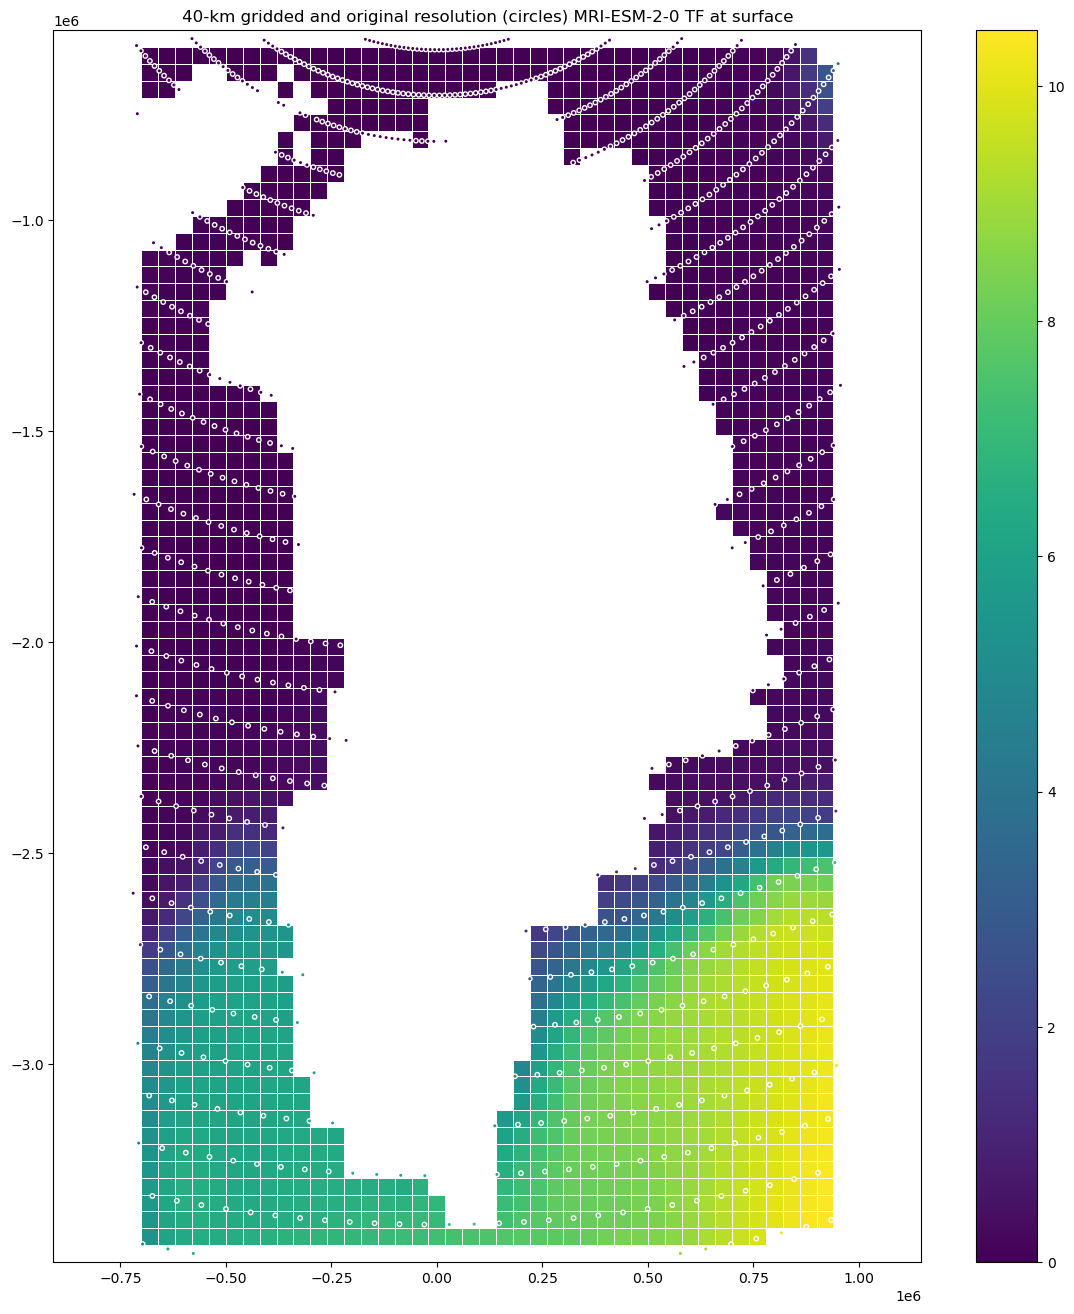

In [9]:
import xarray as xr
import matplotlib.pyplot as plt

# cmip gridding
origfile = '/Users/eultee/Desktop/MRI-ESM2/ssp245/Omon/TF/TF_Omon_MRI-ESM2-0_ssp245_r1i1p1f1_gr_201501-206412_cropped.nc'
dsorig = xr.open_dataset(origfile)
x = dsorig['x'].values
y = dsorig['y'].values
TF = dsorig['TF'].values

# regular gridding
gridfile = '/Users/eultee/Desktop/MRI-ESM2/ssp245/Omon/TF/TF_Omon_MRI-ESM2-0_ssp245_r1i1p1f1_gr_201501-206412_cropped_regrid.nc'
dsgrid = xr.open_dataset(gridfile)
xgrid = dsgrid['x'].values
ygrid = dsgrid['y'].values
TFgrid = dsgrid['TF'].values

# plot
fig = plt.figure(figsize=(14,16))
plt.pcolormesh(xgrid,ygrid,TFgrid[0,0,:,:],edgecolors='w',linewidth=0.5)
plt.scatter(x,y,c=TF[0,0,:],s=10,edgecolors='w')
plt.axis('equal')
plt.title('40-km gridded and original resolution (circles) MRI-ESM-2-0 TF at surface')
plt.colorbar()
plt.show()